In [5]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt

In [7]:
df = pd.read_csv("drawndata1.csv")

In [8]:
df.head(3)

,x,y,z
0,58.080365,225.699042,a
1,238.867357,247.456645,a
2,156.218212,286.588782,a


In [9]:
X = df[['x', 'y']].values
y = df['z'] == 'a'

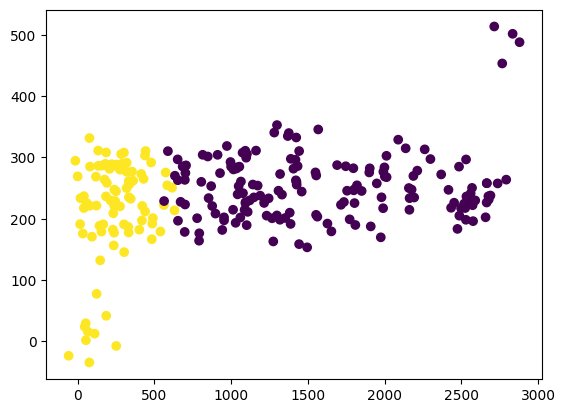

In [10]:
plt.scatter(X[:, 0], X[:, 1], c=y)

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2846: UserWarning: n_quantiles (1000) is greater than the total number of samples (252). n_quantiles is set to n_samples.
  warnings.warn(


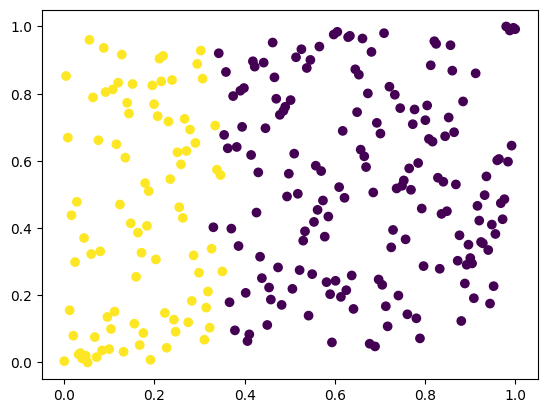

In [23]:
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline 
X_new = QuantileTransformer().fit_transform(X)
plt.scatter(X_new[:, 0], X_new[:, 1], c=y)

(array([ 84., 221., 163., 134.,  89.,  78.,  49.,  45.,  32.,  22.,  23.,
         10.,  12.,  11.,   5.,  11.,   3.,   3.,   1.,   0.,   1.,   0.,
          1.,   0.,   0.,   0.,   1.,   0.,   0.,   1.]),
 array([-1.18078811, -0.90807614, -0.63536417, -0.36265221, -0.08994024,
         0.18277173,  0.45548369,  0.72819566,  1.00090763,  1.2736196 ,
         1.54633156,  1.81904353,  2.0917555 ,  2.36446746,  2.63717943,
         2.9098914 ,  3.18260337,  3.45531533,  3.7280273 ,  4.00073927,
         4.27345123,  4.5461632 ,  4.81887517,  5.09158713,  5.3642991 ,
         5.63701107,  5.90972304,  6.182435  ,  6.45514697,  6.72785894,
         7.0005709 ]),
 <BarContainer object of 30 artists>)

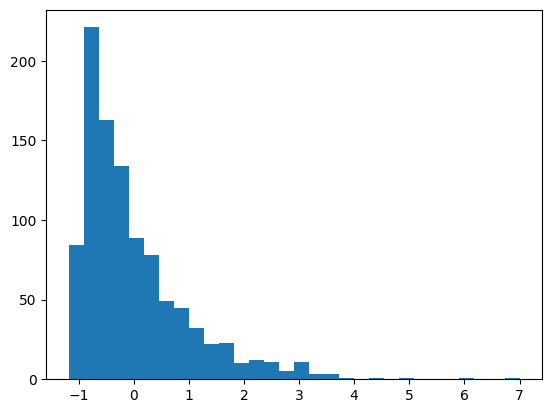

In [24]:
x = np.random.exponential(10, (1000)) + np.random.normal(0, 1, (1000))
plt.hist((x - np.mean(x))/np.std(x), 30)

In [25]:
def plot_output(scaler):
    pipe = Pipeline([
        ("scale", scaler),
        ("model", KNeighborsClassifier(n_neighbors=20, weights='distance'))
    ])

    pred = pipe.fit(X, y).predict(X)

    plt.figure(figsize=(9, 3))
    plt.subplot(131)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.title("Original Data")
    plt.subplot(132)
    X_tfm = scaler.transform(X)
    plt.scatter(X_tfm[:, 0], X_tfm[:, 1], c=y)
    plt.title("Transformed Data")
    plt.subplot(133)
    X_new = np.concatenate([
        np.random.uniform(0, X[:, 0].max(), (5000, 1)), 
        np.random.uniform(0, X[:, 1].max(), (5000, 1))
    ], axis=1)
    y_proba = pipe.predict_proba(X_new)
    plt.scatter(X_new[:, 0], X_new[:, 1], c=y_proba[:, 1], alpha=0.7)
    plt.title("Predicted Data")

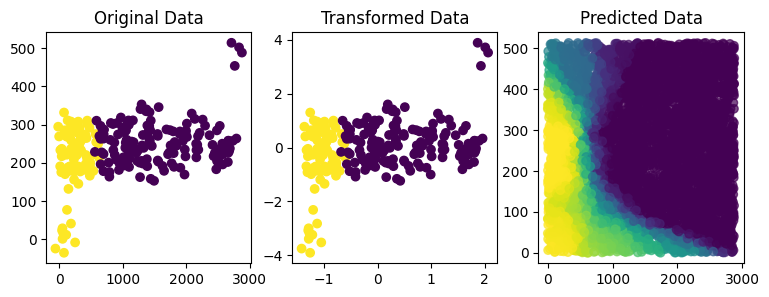

In [26]:
plot_output(scaler=StandardScaler())

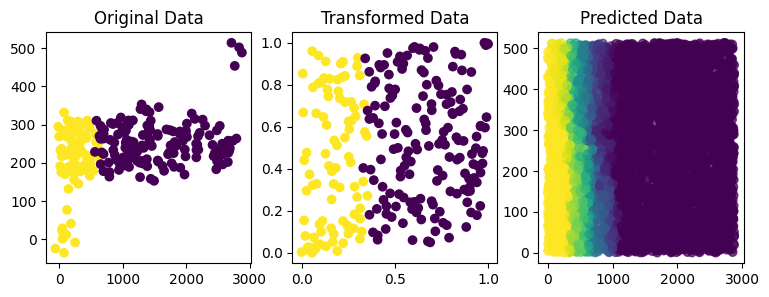

In [27]:
plot_output(scaler=QuantileTransformer(n_quantiles=100))

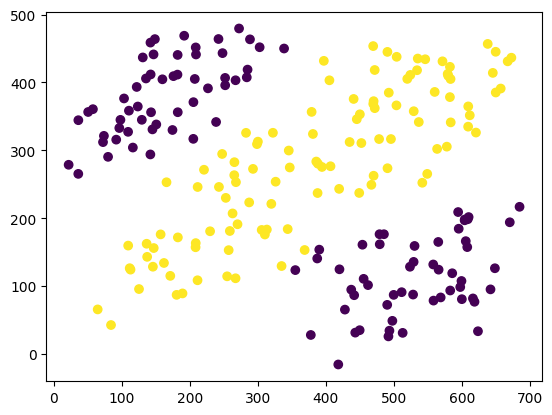

In [28]:
df = pd.read_csv("drawndata2.csv")
X = df[['x', 'y']].values
y = df['z'] == 'a'
plt.scatter(X[:, 0], X[:, 1], c=y);

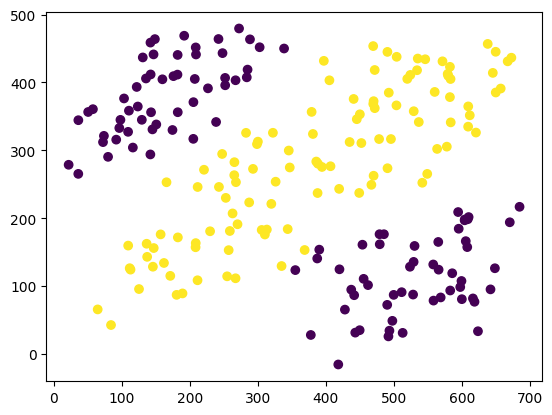

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("scale", PolynomialFeatures()),
    ("model", LogisticRegression())
])

pred = pipe.fit(X, y).predict(X)
plt.scatter(X[:, 0], X[:, 1], c=pred);

In [30]:
arr = np.array(["low", "low", "high", "medium"]).reshape(-1, 1)
arr

array([['low'],
       ['low'],
       ['high'],
       ['medium']], dtype='<U6')

In [31]:
from sklearn.preprocessing import OneHotEncoder

In [37]:
from sklearn.preprocessing import OneHotEncoder